## Import necessary libraries and modules

In [1]:
from random import randint as rnd
from random import shuffle
import numpy as np
import matplotlib.pyplot as plt
import cv2

## Define the number of cities, dimensions for the 2D space, population size, and number of iterations (epochs)

In [2]:
N_CITIES = 8
WIDTH = 500
HEIGHT = 500
POPULATION_SIZE = 100
EPOCH = 200

## random_city_generator

In [3]:
def random_city_generator(n_c, a_w, a_h):
    # offset is the margin kept from the edges so cities are not placed too close to the borders
    offset = 20
    # empty list to store the city locations
    cities = []
    i = 0
    # keep generating cities until the required number (n_c) is reached
    while i < n_c:
        # generate a random position for each city within the given width and height, considering the offset
        city_location = [rnd(offset, a_w - offset), rnd(offset, a_h - offset)]
        # if this location has not already been generated, add it to the list of cities
        if city_location not in cities:
            cities.append(city_location)
            i += 1
    # return the list of generated city locations
    return cities


## initial_population

In [4]:
def init_population(n, ps):
    # empty list to store the population of routes
    population_list = []
    
    # generate the population with size ps
    for i in range(ps):
        # create a list of indices from 0 to n-1 to represent city IDs
        path = [i for i in range(n)]
        # randomly shuffle the order of cities to create a random route
        shuffle(path)
        # add None at the end of the route
        # (it may be used for closing the route or marking the route end)
        path += [None]
        # add the generated route to the population list
        population_list.append(path)
    
    # return the initial population list
    return population_list


## cross_over

In [5]:
def cross_over(population_list, n, p):
    # perform the crossover operation for p routes from the initial population
    for i in range(p):
        # select a route from the population and extract a path slice of size n
        path = population_list[i][:n] + [None]
        # append the new crossover route to the population
        population_list.append(path)
    # return the updated population containing the crossover routes
    return population_list


## mutation

In [6]:
def mutation(population_list, n, p):
    # length of the population pool to apply mutation to (2 * p)
    length = p * 2
    # start index at p (mutating the second half of the population)
    i = p
    
    # loop until reaching the end of the target population slice
    while i < length:
        # select two random city indices to swap (mutation operation)
        cell1 = rnd(0, n-1)
        cell2 = rnd(0, n-1)
        
        # ensure the two selected city indices are different
        if cell1 != cell2:
            # swap the two cities in the route (mutate)
            population_list[i][cell1], population_list[i][cell2] = population_list[i][cell2], population_list[i][cell1]
            # move to the next route in the population
            i += 1
    
    # return the population after mutation
    return population_list


In [7]:
def path_cordinates(cities_locations, path):
    # create an empty list to store coordinates
    cordinates = []
    # add the coordinates of each city in the path to the list
    for i in path:
        cordinates.append(cities_locations[i])
    # return the list of coordinates
    return cordinates


def euclidean_distance(path):
    # variable to store the total distance
    distance = 0
    # calculate the distance between each pair of consecutive cities in the path
    for i in range(len(path) - 1):
        distance += np.sqrt((path[i][0] - path[i + 1][0]) ** 2 + (path[i][1] - path[i + 1][1]) ** 2)
    # return the total distance
    return distance


def fitness(population_list, n, location_list):
    # evaluate the fitness of each route in the population
    for i in range(len(population_list)):
        # if the route has not ended yet (marked with None)
        if population_list[i][-1] == None:
            # convert the route to coordinates and calculate its distance
            current_path = path_cordinates(location_list, population_list[i][:n] + [population_list[i][0]])
            d = euclidean_distance(current_path)
            # store the distance at the end of the route
            population_list[i][n] = d
    # return the population with calculated distances
    return population_list


## sorter

In [8]:
def sorter(population_list, k):
    # sort the population based on the fitness value at index k
    population_list.sort(key=lambda x: x[k])
    # return the sorted population
    return population_list


## draw_cities

In [9]:
def draw_cities(img, cities_locations, color):
    # iterate through each city location in the coordinates list
    for x, y in cities_locations:
        # draw a red circle (0, 0, 255) at position (x, y) with a radius of 6
        img = cv2.circle(img, (x, y), 6, (0, 0, 255), -1)
    # return the image after drawing the cities
    return img


## draw_path

In [10]:
def draw_path(img, path, color):
    # draw a line between each pair of consecutive points in the route
    for i in range(len(path) - 1):
        # draw a line between path[i] and path[i + 1] using the specified color
        img = cv2.line(img, path[i], path[i + 1], color, 2)
    # return the image after drawing the path
    return img


## run

Best found solution: [7, 5, 3, 6, 0, 1, 4, 2, np.float64(1061.5862539894197)]


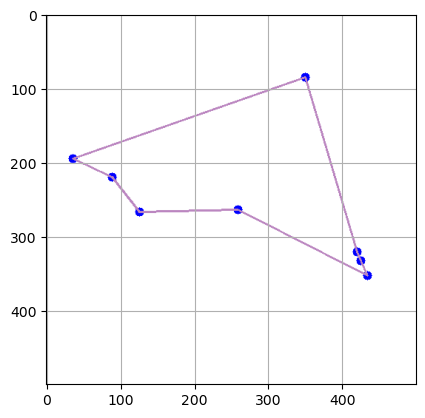

In [11]:
if __name__ == "__main__":
    # Generate random locations for the cities
    cities_locations = random_city_generator(N_CITIES, WIDTH, HEIGHT)
    # Create the initial population of routes
    current_population = init_population(N_CITIES, POPULATION_SIZE)
    
    # Main loop to execute the Genetic Algorithm
    for i in range(1, EPOCH + 1):    
        # Perform crossover operations on the population
        current_population = cross_over(current_population, N_CITIES, POPULATION_SIZE)  
        # Apply mutation to the population
        current_population = mutation(current_population, N_CITIES, POPULATION_SIZE)
        # Calculate fitness (distance) for the population
        current_population = fitness(current_population, N_CITIES, cities_locations)
        # Sort the population based on fitness values
        current_population = sorter(current_population, N_CITIES)
        # Keep only the best routes up to the population size
        current_population = current_population[:POPULATION_SIZE]

    else:
        # Print the best solution found
        print("Best found solution:", current_population[0])
        # Create a white canvas to display the cities and the route
        area = np.full((WIDTH, HEIGHT, 3), 255, np.int16)
        # Draw cities on the image
        area = draw_cities(area, cities_locations, (0, 0, 255))
        # Convert the best route's indices to coordinates
        current_path = path_cordinates(cities_locations, current_population[0][:N_CITIES])
        # Close the route (connect the last city back to the first one)
        current_path += [current_path[0]] 
        # Draw the optimal path on the image
        area = draw_path(area, current_path, (187, 134, 192))
        
        # Display the final visualization
        plt.imshow(area)
        plt.grid()
        plt.show()
